# Task - EDA of the Iris Dataset

* Your task is to perform an analysis of the data contained in the attached CSV file (`25__iris.csv`).
* Use your newly acquired knowledge of the `Pandas` library.
* Remember:

1. Don’t rush  
2. Treat this homework as a real project  
3. Add descriptions, observations, and conclusions  
4. Include visualizations  
5. Provide a final summary and conclusions  

Good luck! And have lots of fun!

## About the Data

The dataset contains information about three species of iris flowers: *Iris setosa*, *Iris versicolor*, and *Iris virginica*.

The data includes measurements of four features: sepal length, sepal width, petal length, and petal width.

Each row in the dataset represents a single flower, and the measurement values are given in centimeters.

The dataset consists of 150 samples - 50 for each species - and is widely used as a fundamental dataset for testing classification algorithms, as well as in data science and machine learning.

**Columns:**
* **sepal length** - length of the sepal in cm  
* **sepal width** - width of the sepal in cm  
* **petal length** - length of the petal in cm  
* **petal width** - width of the petal in cm  
* **class** - iris species (setosa, versicolor, virginica)


`========================================================================================================================================================`

## Objective of the Analysis

The goal of this project is to understand the characteristics of different iris species (`Iris-setosa`, `Iris-versicolor`, `Iris-virginica`) based on morphological measurements of their flowers.

We aim to answer the following questions:

- Do the features (lengths and widths) differ between species?  
- Which features best distinguish the species from one another?  
- Is visual or statistical classification possible based on these data?  


## Analysis Stages and Description of Actions

### 1. Data Import and Environment Setup
- A brief reminder of the biological context of the terms “petal” and “sepal” (if previously introduced, this can refer to an illustration for the client).  
- Load the dataset using the `pandas` library.  
- Before proceeding with the analysis, ensure that the data are complete and consistent.  
- Check the basic structure of the data (shape, data types, missing or unique values).  

### 2. Descriptive Statistics and Observations
- Calculate means, standard deviations, minimum and maximum values.  
- Divide the analysis by class (species).  
- Initial conclusions: which species show the highest or lowest values for each feature?  

### 3. Data Visualization
- **Boxplots and histograms**: distributions of each feature.  
- **Scatter plots**: analysis of spatial separation between species.  
- Color the points by species to improve the readability of the plots.  

### 4. Correlation Analysis
- Calculate a correlation matrix between all features (e.g., petal length vs. petal width).  
- Identify features that are strongly correlated, both positively and negatively.  

### 5. Summary and Final Conclusions
- Gather the key observations.  
- Indicate which features best differentiate the iris species.  
- Assess whether the data are sufficient as a foundation for a classification model (e.g., for machine learning).


## Personal Observation about the “Sepal” That Isn’t Really a Sepal

I began working on this analysis by trying to understand what the features in the `iris.csv` dataset actually represent.  
I came across something interesting and perhaps misleading: the data include variables named **“sepal length”** and **“sepal width.”**

As someone who wanted to approach the topic thoroughly, I started to ask myself: _does the iris flower actually have a sepal?_  
And here came the surprise. In botanical terms, the iris does **not** have a traditional sepal. Its flowers are composed of six tepals-three outer ones (called “falls”) and three inner ones (“standards”).

**Therefore, the term “sepal” in this dataset is a simplification** a reference to the English term _sepal_ (meaning “calyx lobe”), which doesn’t exist in the typical form for irises.  
It’s a convenient shorthand used for statistical and classification purposes rather than for strict biological accuracy.

So, I decided to interpret these data as they are presented fully aware that:

- _“sepal”_ actually refers to the **outer tepal** (_fall_),  
- _“petal”_ refers to the **inner tepal** (_standard_).



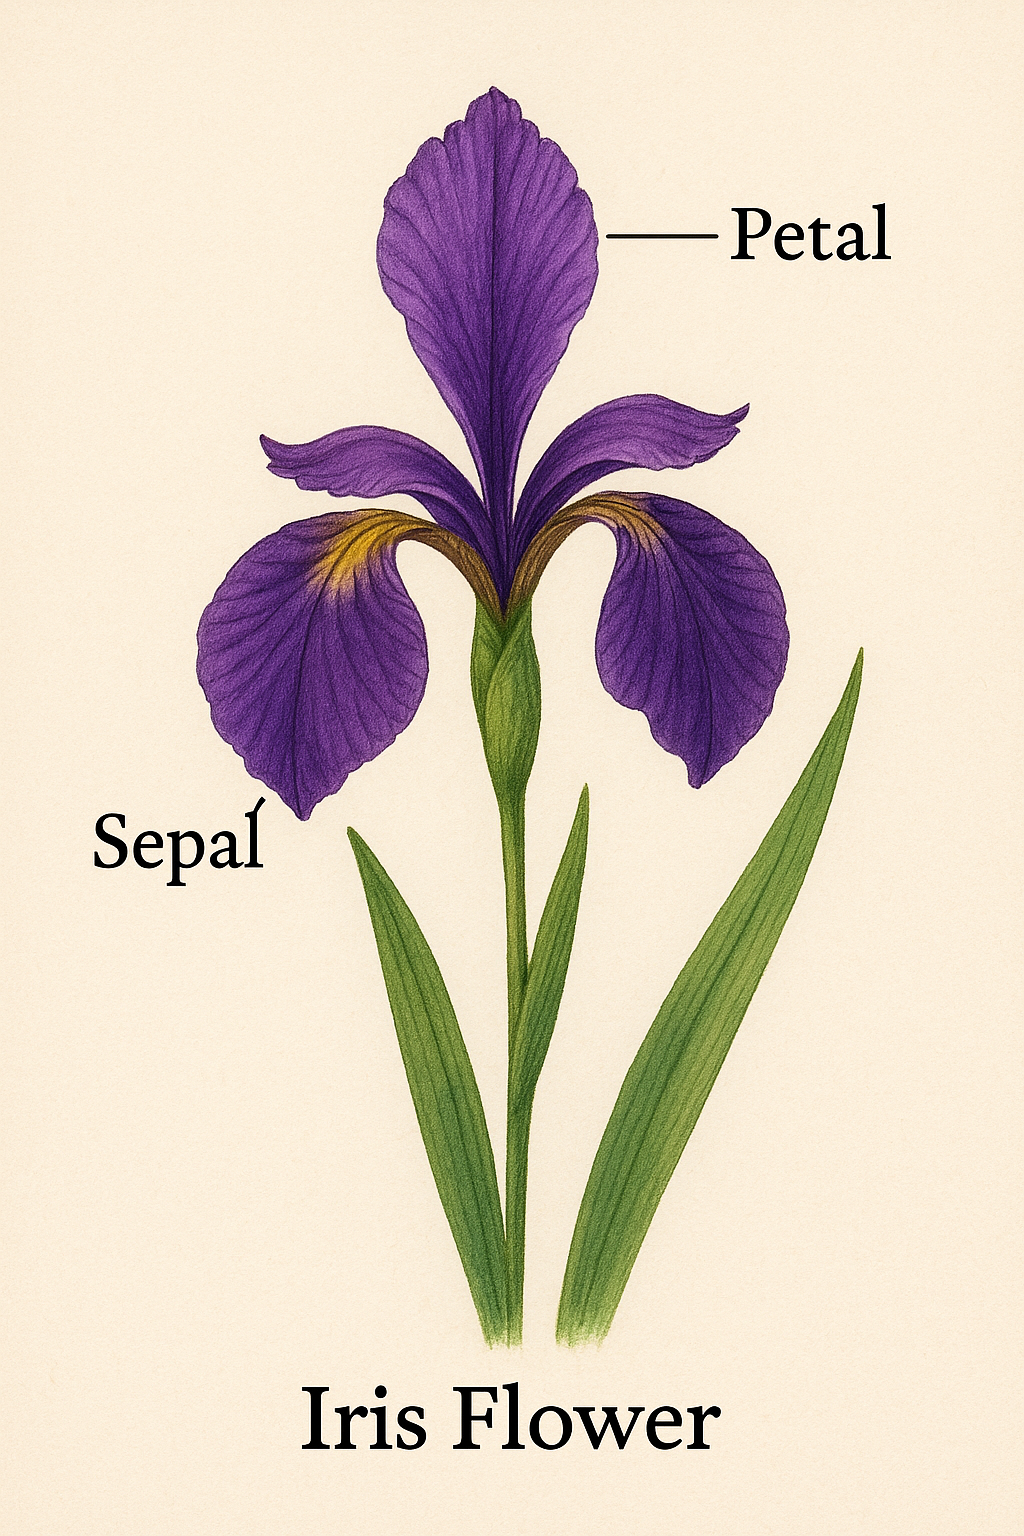

In [1]:
from IPython.display import display, HTML
import base64

# Read the image file and encode it as base64
with open("1.png", "rb") as image_file:
    encoded = base64.b64encode(image_file.read()).decode()

# Create HTML markup with the embedded image
html = f'''
<h3>Structure of the Iris Flower – Illustration</h3>
<p>The image below shows what the iris flower looks like from a botanical perspective. 
It helped me better understand why the variable names in the `iris.csv` dataset can be a bit confusing.</p>
<img src="data:image/png;base64,{encoded}" width="600"/>
<p style="font-style: italic;">The illustration shows the actual parts of the iris flower. 
What the dataset calls a “sepal” actually refers to the outer tepals (known as “falls”), 
while the “petals” correspond to the inner tepals (known as “standards”).</p>
'''

display(HTML(html))


In [2]:
import pandas as pd
df = pd.read_csv('25__iris.csv', sep=",")
df

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width),klasa (class)
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
# Rename columns from Polish to English
df = df.rename(columns={
    "długość kielicha (sepal length)": "sepal_length",
    "szerokość kielicha (sepal width)": "sepal_width",
    "długość płatka (petal length)": "petal_length",
    "szerokość płatka (petal width)": "petal_width",
    "klasa (class)": "class"
})

# Display the first few rows to confirm the change
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


---

## Before starting the actual analysis of the `iris.csv` dataset and the morphological characteristics of individual iris species, it is essential to ensure that the data are consistent, complete, and reliable.  
Such preliminary verification is crucial, as any analysis performed on incorrect data can lead to false conclusions.  
These initial steps are intended to confirm that the dataset is ready for further exploration and statistical interpretation.


## Checking for Missing Values in Columns

Missing values may indicate errors in data entry or improper data loading.  
It is important to verify that all columns contain complete information before proceeding with further analysis.

In [5]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

## Conclusions

The dataset is complete - each column contains a full set of values for all observations.  
No empty cells or `NaN` values were found, which indicates good data quality at this stage of the analysis.

---

## Checking Class Distribution

Before proceeding with further analysis, I will check how many observations belong to each iris species.  
This allows me to assess whether the dataset is balanced; that is, whether each class (species) has a similar number of examples.  

I will use the `value_counts()` method, which counts the occurrences of each unique value in the `class` column.  
For consistency, I will sort the results alphabetically.

In [1105]:
df["class"].value_counts().sort_index()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## Conclusions

All three species (*Iris-setosa*, *Iris-versicolor*, *Iris-virginica*) are represented by exactly 50 observations each.  
The data are therefore perfectly balanced, which supports reliable comparative analysis and potential modeling.

---

## Checking for Possible Duplicates

Duplicate rows can distort the analysis.  
They may result from data collection errors or technical artifacts.  
Such entries should only be removed if they are not justified or do not represent meaningful repetitions.

In [1106]:
df.duplicated().sum()

3

## Overview of Duplicate Records

Three duplicate rows were detected.  
Before removing them, it is worth analyzing their context, in nature, it is possible for several flowers of the same species to have identical measurements.  
For this reason, duplicates are not automatically treated as errors but should be evaluated in context.

In [1107]:
df[df.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,class
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
142,5.8,2.7,5.1,1.9,Iris-virginica


## Conclusions

Three duplicate records were found in the dataset. After a careful review, it was determined that:

- with 150 samples in total, this is not unusual,  
- these are isolated cases, several flowers could naturally have identical measurements,  
- the values fall within the normal distribution range,  
- the duplicates are not repeated excessively (e.g., 10 times),  
- they do not appear only at the beginning or end of the file, so there is no clear indication of a technical error,  
- the repetitions may result from natural similarity among flowers of the same species.  

No technical issues were identified in the data. The duplicates **remain in the dataset** and will not be removed.

---

## Checking for Suspicious Values

Here I check for suspicious values, such as zeros or negative numbers, in columns where they should not appear.  
Since lengths and widths cannot be negative, this step helps identify any obvious logical errors in the data.

In [1108]:
(df.select_dtypes(include='number') < 0).sum()


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64

## Conclusions

All morphological feature values (sepal and petal lengths and widths) are positive.  
This is consistent with biological reality and indicates that there are no errors caused by incorrect data loading or encoding.

---

## Examining Basic Statistical Measures of the Variables

At this stage, I review the basic descriptive statistics for each numerical feature.  
This helps me understand the range and variability of each measurement (e.g., the lengths and widths of petals and sepals).

Using the `describe()` method, I can observe whether any feature contains unusual outliers, whether the distribution of values is relatively symmetric, and how large the spread is between the minimum and maximum values.


In [1109]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Conclusions

Below is a summary of the statistical characteristics of the numerical features in the `iris.csv` dataset.  
It provides an initial overview of data distribution, helps detect potential outliers or irregularities, and offers a better understanding of the scale of each variable:

| Feature                   | Min - Max | Mean Value | Standard Deviation (std) | Comment |
|----------------------------|-----------|-------------|---------------------------|----------|
| **Sepal length**           | 4.3 - 7.9 | 5.84        | 0.83                      | Low variability, values evenly distributed. |
| **Sepal width**            | 2.0 - 4.4 | 3.05        | 0.43                      | Mean close to median (3.0), relatively symmetric distribution. |
| **Petal length**           | 1.0 - 6.9 | 3.76        | 1.76                      | Largest spread, maximum value significantly higher than the mean. |
| **Petal width**            | 0.1 - 2.5 | 1.20        | 0.76                      | Possible presence of outliers on the lower end. |

- All features contain 150 observations (no missing data).  
- Some variables, such as petal length, show high variability, which may indicate strong discriminative power for species classification.  
- No suspicious extreme values were found.  

No alarming issues were detected at this stage, the dataset is ready for further analysis.


---

## Checking Label Consistency and Recognizing Classes

In this step, I want to ensure that all text data, especially the species names are written consistently.  
Even small differences in formatting, such as *Iris-setosa* vs *iris-setosa*, can cause the data to split unnecessarily into multiple categories.

Therefore, I will check which unique values appear in the text-based columns (e.g., the species class column).

In [1110]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

class: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## Conclusions

- The dataset contains **three distinct iris species**,  
- These are: `Iris-setosa`, `Iris-versicolor`, and `Iris-virginica`,  
- The data match the expected set of classes from the classic Iris dataset,  
- No suspicious, incorrect, or inconsistent labels were found the classification labels appear to be clean and reliable.  

In the following analysis, I will explore how the measurable features differentiate these three plant species.

---

## Checking Data Types

The data type of each column is important.  
Numerical operations will work correctly only if the data are stored in an appropriate format (e.g., `float` or `int`).  

Here, I verify whether numerical data are indeed of numeric type and whether categorical data are of text type (`object`).  
If necessary, they can be converted to the proper format.


In [1111]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
class            object
dtype: object

## Conclusions

All columns containing numerical values are correctly encoded as `float64`, which means they are ready for statistical analysis and visualization.  
The `class` column is of type `object`, as expected, since it contains textual species labels.  
There is no need for any data type conversion the dataset is ready for further analysis.


---

## The Final Step of Stage One - Checking for Unreadable or Empty String Values

Sometimes datasets contain placeholders such as `"NaN"`, spaces, dashes (`-`), question marks (`?`), or words like `"missing"`, `"none"`, or `"brak"` written as text.  
These should be identified, as they may represent missing or invalid values that were not properly encoded as `NaN`.


In [1112]:
df.apply(lambda x: x.unique() if x.dtype == 'object' else None)

sepal_length                                              None
sepal_width                                               None
petal_length                                              None
petal_width                                               None
class           [Iris-setosa, Iris-versicolor, Iris-virginica]
dtype: object

## Conclusions

The numerical columns contain too many unique values to be displayed in full, which confirms that they represent continuous (measurable) variables.  
The `class` column contains exactly three unique values, consistent with the expected set of iris species.  
No anomalies such as typos, mismatched values, empty entries, or incorrectly encoded data were detected.  

The dataset is consistent and fully ready for the detailed analysis of features for each species.


---

## In this section, I perform a statistical summary of the morphological features of flowers, grouped by species.  
This allows me to identify differences between species in terms of:
- sepal length and width (the outer part of the perianth),  
- petal length and width (the inner part of the perianth).  

I use the `groupby()` method combined with `describe()` to calculate, among other things, the mean, standard deviation, and minimum/maximum values for each feature and each species.

In [1113]:
df.groupby("class").describe().T
#T he groupby("class") method groups the data by iris species.
# The describe() function generates summary statistics (count, mean, std, min, quartiles, max).
# The .T at the end transposes the table to make it easier to read, showing features in rows and statistics in columns.

class               Iris-setosa  Iris-versicolor  Iris-virginica
sepal_length count    50.000000        50.000000       50.000000
             mean      5.006000         5.936000        6.588000
             std       0.352490         0.516171        0.635880
             min       4.300000         4.900000        4.900000
             25%       4.800000         5.600000        6.225000
             50%       5.000000         5.900000        6.500000
             75%       5.200000         6.300000        6.900000
             max       5.800000         7.000000        7.900000
sepal_width  count    50.000000        50.000000       50.000000
             mean      3.418000         2.770000        2.974000
             std       0.381024         0.313798        0.322497
             min       2.300000         2.000000        2.200000
             25%       3.125000         2.525000        2.800000
             50%       3.400000         2.800000        3.000000
             75%       3.675000         3.000000        3.175000
             max       4.400000         3.400000        3.800000
petal_length count    50.000000        50.000000       50.000000
             mean      1.464000         4.260000        5.552000
             std       0.173511         0.469911        0.551895
             min       1.000000         3.000000        4.500000
             25%       1.400000         4.000000        5.100000
             50%       1.500000         4.350000        5.550000
             75%       1.575000         4.600000        5.875000
             max       1.900000         5.100000        6.900000
petal_width  count    50.000000        50.000000       50.000000
             mean      0.244000         1.326000        2.026000
             std       0.107210         0.197753        0.274650
             min       0.100000         1.000000        1.400000
             25%       0.200000         1.200000        1.800000
             50%       0.200000         1.300000        2.000000
             75%       0.300000         1.500000        2.300000
             max       0.600000         1.800000        2.500000

## Conclusions 

### Petal Length:
- *Iris-setosa* has the shortest petals (average around 1.5 cm),  
- *Iris-virginica* has the longest (average around 5.5 cm),  
- *Iris-versicolor* falls in between.  

### Petal Width:
- Also the narrowest in *setosa* (approx. 0.25 cm) and the widest in *virginica* (approx. 2.0 cm).  

### Sepal (sepal length and width):
- The differences are less pronounced, but *virginica* has the longest sepals (around 6.5 cm),  
  while *setosa* stands out slightly with a greater average sepal width (~3.4 cm).  

### Summary:
*Iris-setosa* has morphological features that clearly distinguish it from the other species.  
*Iris-versicolor* and *Iris-virginica* are more similar to each other, especially regarding sepal features.  
*Iris-setosa* has the smallest petals and sepals (the perianth segments), particularly in both petal length and width, which makes it easily recognizable compared to the other species.


---

## Summary of Maximum Values

To better understand the characteristics of each iris species, I compile the records containing the maximum values for each feature (length and width of petals and sepals).  
This helps assess which classes dominate in terms of the size of specific flower parts.

In [1114]:
# Create an empty DataFrame to store rows with maximum values
highest_values = pd.DataFrame()

# Loop through each numerical feature and find the record with the maximum value
for column in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    index = df[column].idxmax()
    highest_values = pd.concat([highest_values, df.loc[[index]]])

# Remove possible duplicates (in case the same record has multiple max values)
highest_values.drop_duplicates(inplace=True)
highest_values.reset_index(drop=True, inplace=True)

# Display the final DataFrame with the highest values
highest_values


,sepal_length,sepal_width,petal_length,petal_width,class
0,7.9,3.8,6.4,2.0,Iris-virginica
1,5.7,4.4,1.5,0.4,Iris-setosa
2,7.7,2.6,6.9,2.3,Iris-virginica
3,6.3,3.3,6.0,2.5,Iris-virginica


## Conclusions Illustrated by the Code Below

The following table shows specific rows from the dataset where maximum values were recorded, along with their corresponding species:

- **Iris-virginica** is the most robust species it reaches the largest dimensions in almost every category.  
- **Iris-setosa** stands out in only one case it has the widest sepal, although overall it is smaller than the other species.


In [1115]:
# Find maximum values for all numeric columns
max_values = df.select_dtypes(include='number').max()

# Create an empty DataFrame to store records with maximum values
max_records = pd.DataFrame()

# Loop through each numeric column and extract the row with the maximum value
for col in max_values.index:
    row = df[df[col] == max_values[col]].iloc[0]   # first record with the maximum value
    row_info = row.to_frame().T                   # convert Series to one-row DataFrame
    row_info['feature'] = col
    row_info['maximum_value'] = max_values[col]
    max_records = pd.concat([max_records, row_info], ignore_index=True)

# Display selected columns: feature name, maximum value, and species class
max_records[["feature", "maximum_value", "class"]]


,feature,maximum_value,class
0,sepal_length,7.9,Iris-virginica
1,sepal_width,4.4,Iris-setosa
2,petal_length,6.9,Iris-virginica
3,petal_width,2.5,Iris-virginica


Such a summary can be useful in later stages of the analysis, for example in classification or visualization tasks.

---

## Similarly, a Summary of Minimum Values

Below are the records showing the minimum values for each feature in the dataset.


In [1116]:
# Create an empty DataFrame to store rows with minimum values
lowest_values = pd.DataFrame()

# List of features to check
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Loop through each feature and find the record with the minimum value
for column in features:
    index = df[column].idxmin()
    lowest_values = pd.concat([lowest_values, df.loc[[index]]])

# Remove duplicates (in case the same record has multiple minimums)
lowest_values.drop_duplicates(inplace=True)
lowest_values.reset_index(drop=True, inplace=True)

# Display the final DataFrame with the lowest values
lowest_values

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.3,3.0,1.1,0.1,Iris-setosa
1,5.0,2.0,3.5,1.0,Iris-versicolor
2,4.6,3.6,1.0,0.2,Iris-setosa
3,4.9,3.1,1.5,0.1,Iris-setosa


## Conclusions

To gain a more complete understanding of the data structure, I compiled the records corresponding to the lowest values of each measured feature — both sepal and petal length and width.  
The following table presents the records with the minimum values, allowing me to see which flowers in the dataset have the smallest dimensions and which species they belong to.

In [1117]:
# Find minimum values for all numeric columns
min_values = df.select_dtypes(include='number').min()

# Create an empty DataFrame to store records with minimum values
min_records = pd.DataFrame()

# Loop through each numeric column and extract the row with the minimum value
for col in min_values.index:
    row = df[df[col] == min_values[col]].iloc[0]   # first record with the minimum value
    row_info = row.to_frame().T                   # convert Series to a one-row DataFrame
    row_info['feature'] = col
    row_info['minimum_value'] = min_values[col]
    min_records = pd.concat([min_records, row_info], ignore_index=True)

# Display selected columns: feature name, minimum value, and species class
min_records[["feature", "minimum_value", "class"]]


,feature,minimum_value,class
0,sepal_length,4.3,Iris-setosa
1,sepal_width,2.0,Iris-versicolor
2,petal_length,1.0,Iris-setosa
3,petal_width,0.1,Iris-setosa


The smallest values of petal length, petal width, and sepal length occur in *Iris-setosa*, confirming its overall smaller size.  
*Iris-virginica* has the narrowest sepal width, which is an interesting exception compared to the other features.

---

## Ratio Analysis: Width to Length

To better understand the shape of each flower part, I calculate the ratio of width to length separately for sepals and petals.  
These proportions can reveal which species have more “rounded” features and which have more slender shapes.

The goals are to:
- identify morphological differences in flower structure between species,  
- determine whether any species stands out significantly in terms of proportions,  
- strengthen the subsequent descriptive analysis.


In [1118]:
# Create ratio columns (width divided by length)
df["sepal_ratio"] = df["sepal_width"] / df["sepal_length"]
df["petal_ratio"] = df["petal_width"] / df["petal_length"]

# Then calculate average proportions for each species
proportion_by_class = df.groupby("class")[[
    "sepal_length",
    "sepal_width",
    "sepal_ratio",
    "petal_length",
    "petal_width",
    "petal_ratio"
]].mean().round(2)

# Display the resulting DataFrame
proportion_by_class

,sepal_length,sepal_width,sepal_ratio,petal_length,petal_width,petal_ratio
class,,,,,,
Iris-setosa,5.01,3.42,0.68,1.46,0.24,0.17
Iris-versicolor,5.94,2.77,0.47,4.26,1.33,0.31
Iris-virginica,6.59,2.97,0.45,5.55,2.03,0.37


## Conclusions

To better understand the shape of each part of the iris flower, the following proportions were calculated:
- **sepal_ratio** = sepal width / sepal length  
- **petal_ratio** = petal width / petal length  

These proportions provide a clearer idea of shape than length and width alone.  
A ratio of **0.25** means that the element is four times longer than it is wide - indicating a slender shape,  
while a ratio of **0.75** suggests a more compact or rounded form.

- **Iris-setosa:** the shortest petals but relatively wide ones - high ratio - more compact shape,  
- **Iris-virginica:** long and slender petals - low ratio,  
- **Iris-versicolor:** intermediate values for all features.  

This comparison may be useful for classification purposes, as it shows that proportions can serve as additional distinguishing features between species.


---

## Analysis of Standard Deviation for Each Feature by Class

To better understand the variability of feature values within each species, I calculated the standard deviation for each numerical variable (petal and sepal length/width) grouped by class.  
The standard deviation indicates how much the measurements vary within a given class — the higher the value, the greater the diversity of measurements.

In [1119]:
# Calculate standard deviation for each numerical feature grouped by species
std_deviation = df.groupby("class").std(numeric_only=True)

# Display the result
std_deviation


,sepal_length,sepal_width,petal_length,petal_width,sepal_ratio,petal_ratio
class,,,,,,
Iris-setosa,0.352490,0.381024,0.173511,0.107210,0.051854,0.067306
Iris-versicolor,0.516171,0.313798,0.469911,0.197753,0.046829,0.029213
Iris-virginica,0.635880,0.322497,0.551895,0.274650,0.047015,0.050232


## Conclusions

*Iris-setosa* stands out with very low standard deviations, indicating that individuals of this species have highly consistent and uniform features.  
*Iris-versicolor* and *Iris-virginica* show greater variability, especially in petal length and width.  
The highest variation in measurements is observed in *Iris-virginica*, which may suggest greater diversity among individuals of this species.  

From a classification perspective, such differences are significant - the more dispersed the data, the more challenging it becomes to assign samples clearly to a single class.

---

## Since the `pandas` library has limited visualization capabilities, I will use more advanced tools.  
For this purpose, I will import two libraries:  
- `import matplotlib.pyplot as plt`  
- `import seaborn as sns`  

## With these libraries, I can create clear and visually appealing plots such as boxplots, histograms, and scatter plots for the Iris dataset.

## Boxplots – Examining Feature Distribution by Species
Here I will observe how the values of each feature (sepal and petal length and width) differ among the three iris species.

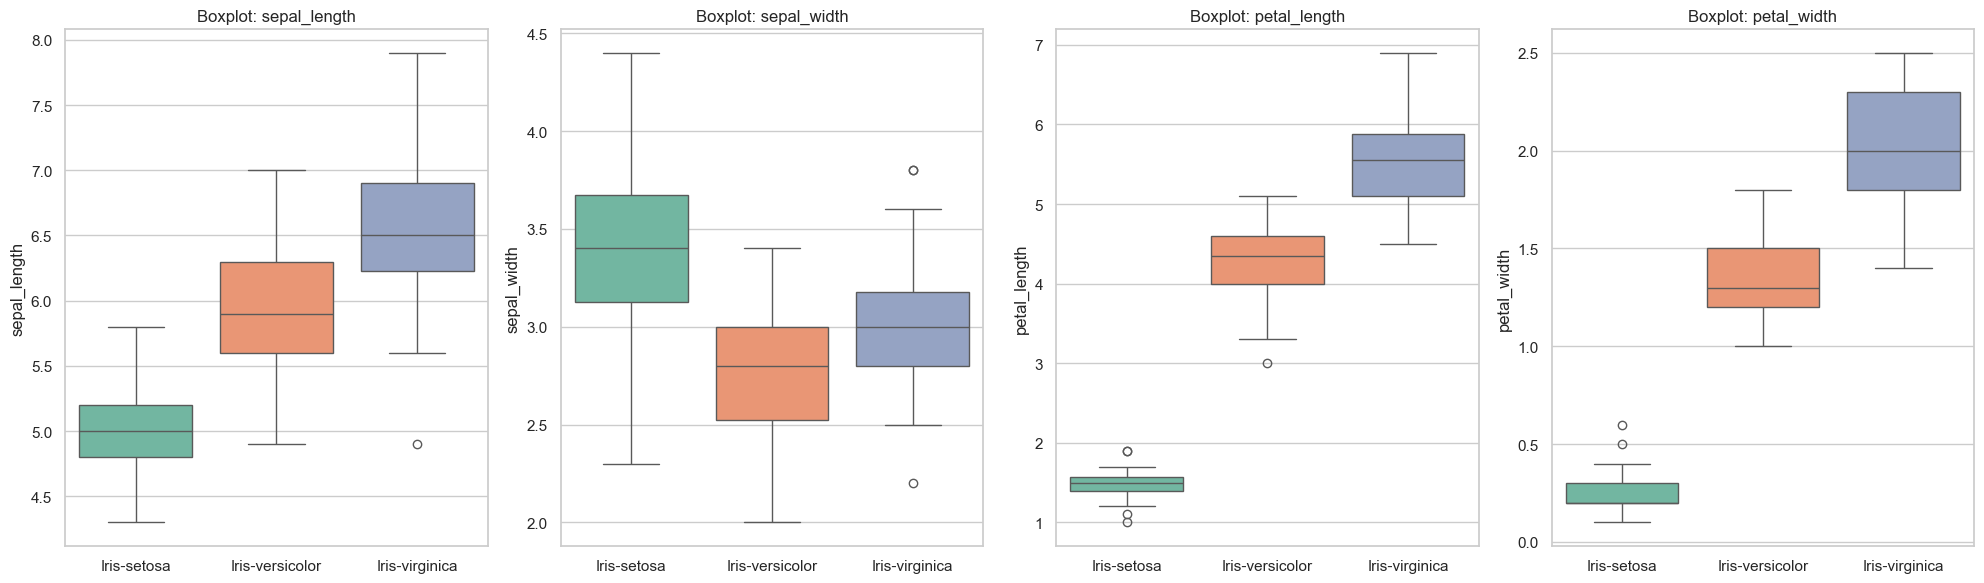

In [1120]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Ensure English column names
df.rename(columns={
    'sepal length': 'sepal_length',
    'sepal width': 'sepal_width',
    'petal length': 'petal_length',
    'petal width': 'petal_width',
    'class': 'class'
}, inplace=True)

# Boxplots for each numerical feature by species
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, col in zip(axes, df.columns[:-1]):
    sns.boxplot(data=df, x='class', y=col, hue='class', legend=False, palette="Set2", ax=ax)
    ax.set_title(f'Boxplot: {col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


## Conclusions

The boxplots show the median, quartiles, and outliers for each feature, grouped by species (*Iris-setosa*, *Iris-versicolor*, *Iris-virginica*).  
The species differ significantly in both petal length and petal width.  
*Iris-setosa* has noticeably smaller petals, making it easy to distinguish.  
*Iris-versicolor* and *Iris-virginica* partially overlap, but the differences are still clearly visible.

---

## Histograms - Examining the Distribution of Feature Values
Here I will explore how the values of each feature are distributed within the dataset and whether different species occupy distinct value ranges.

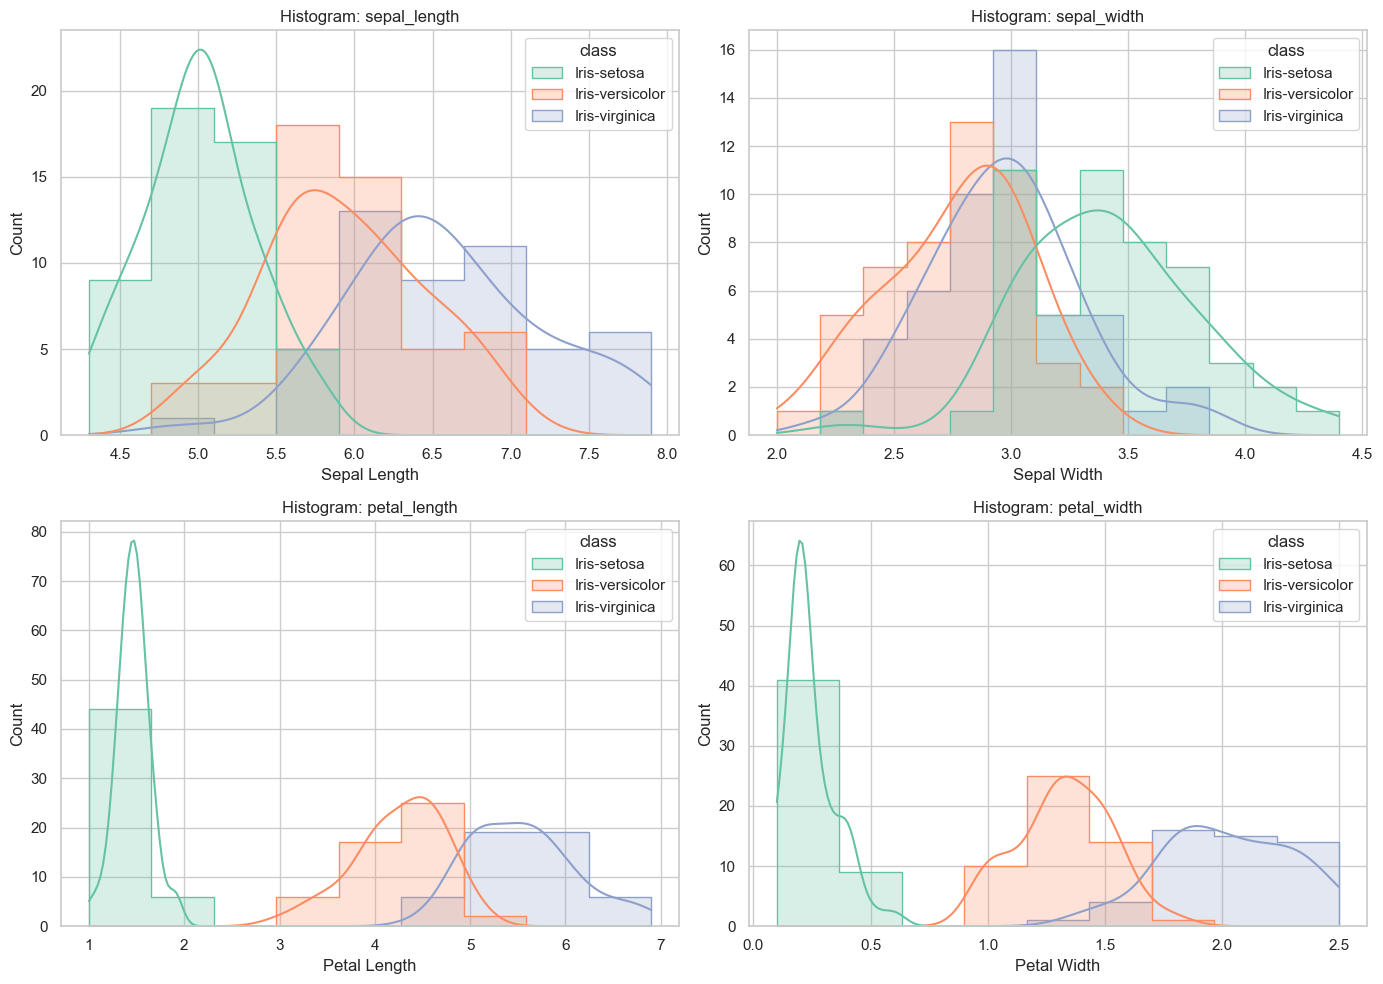

In [1121]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, col in zip(axes.flat, columns):
    sns.histplot(
        data=df, 
        x=col, 
        hue='class', 
        kde=True, 
        element="step", 
        ax=ax,
        palette="Set2"
    )
    ax.set_title(f'Histogram: {col}', fontsize=12)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## Conclusions
The histograms show the frequency distribution of each feature, with colors distinguishing the species.  
Petal length is a well-separating feature — its distributions are clearly distinct between species.  
Sepal width, on the other hand, shows significant overlap between species, making it less useful for classification.  
Overall, the histograms confirm the observations made from the boxplots.

---

## Scatter Plots - Examining Pairwise Feature Relationships
Here I will explore how different features relate to each other and whether certain feature combinations allow for clear separation between species.

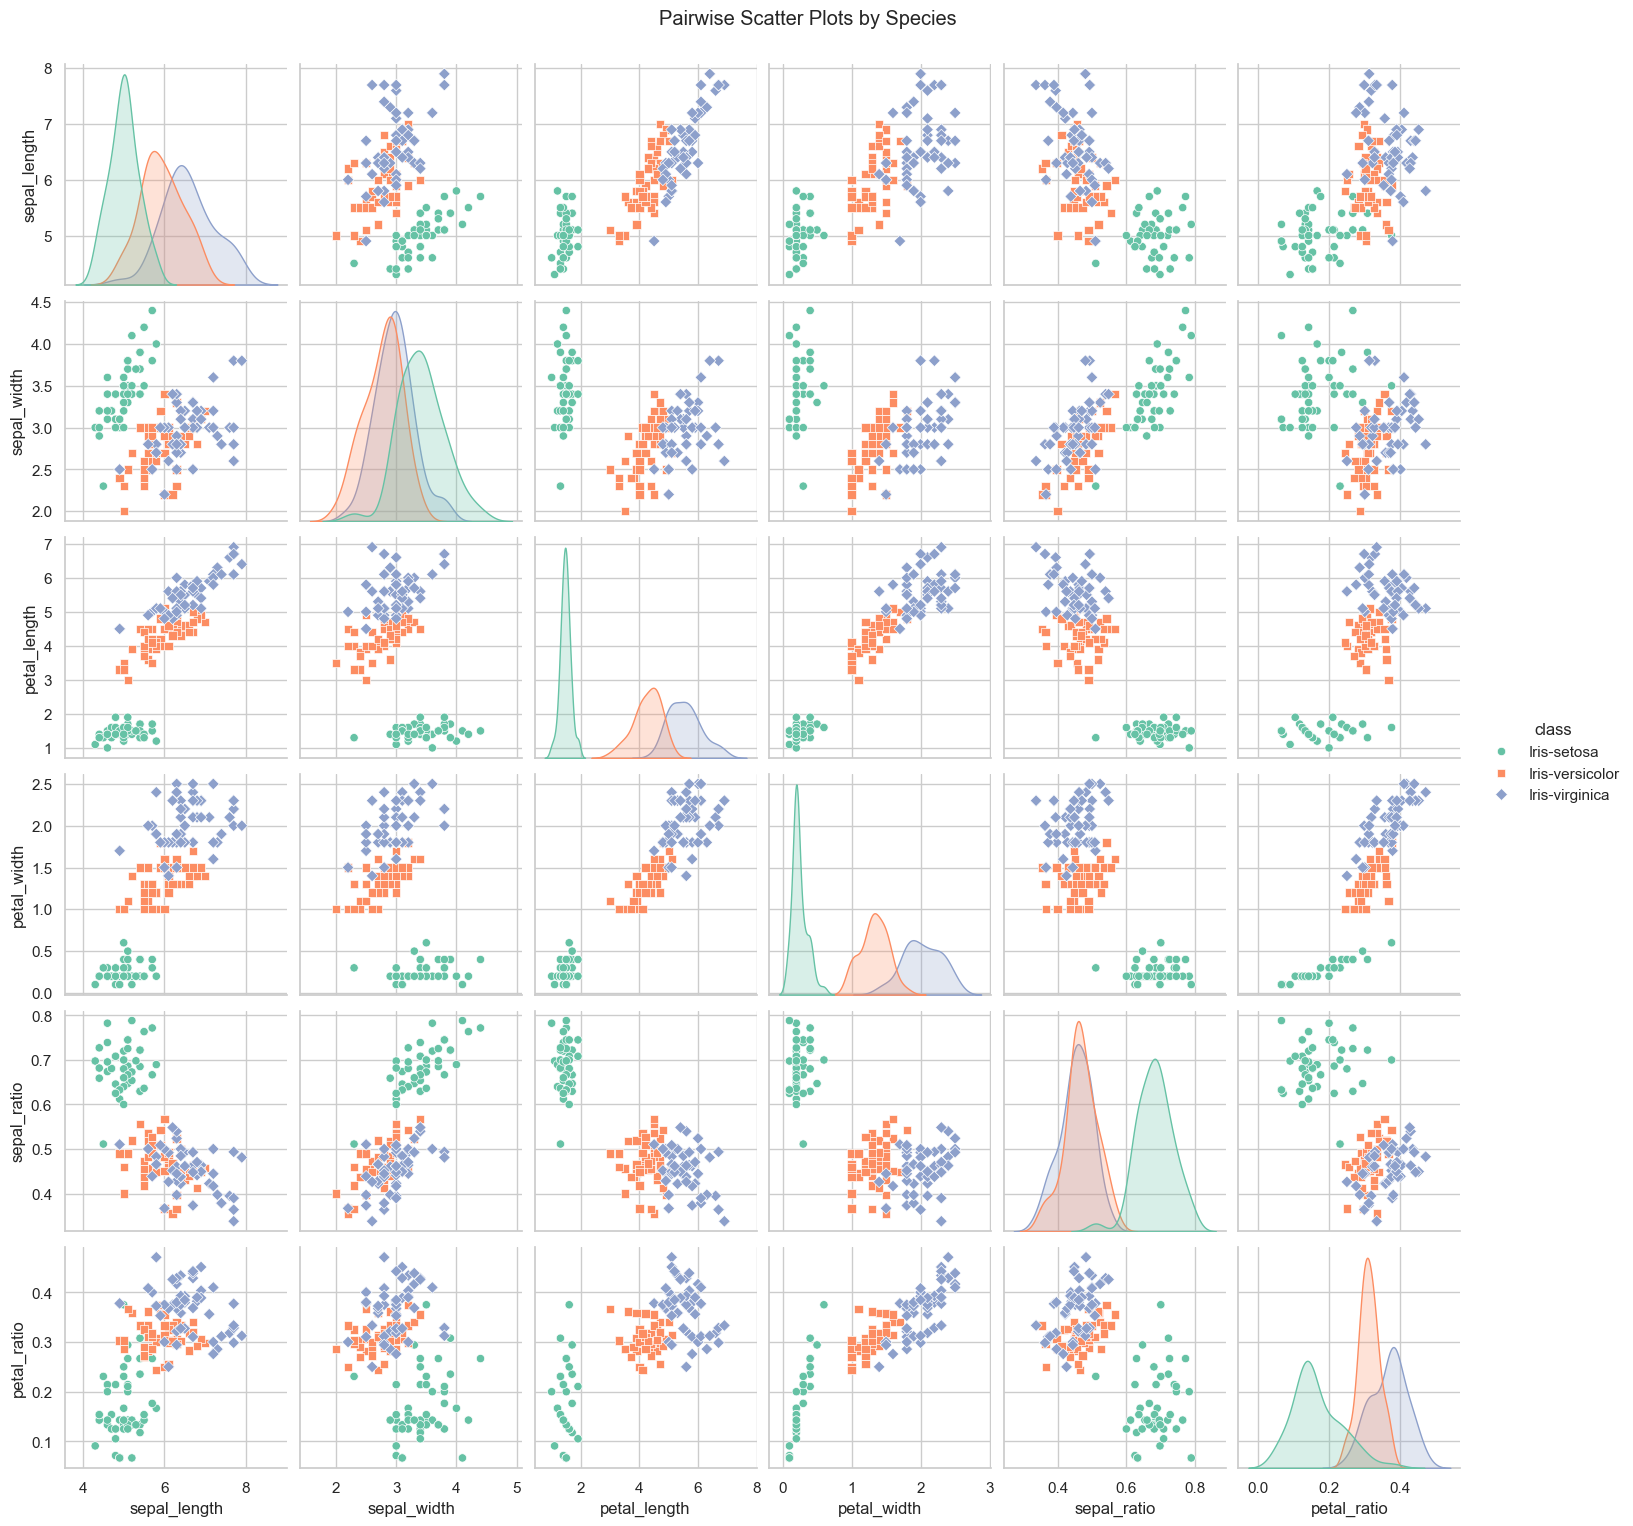

In [1122]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Pairplot to visualize pairwise relationships between features
pair_plot = sns.pairplot(
    df, 
    hue="class", 
    markers=["o", "s", "D"], 
    diag_kind="kde", 
    palette="Set2"
)
pair_plot.fig.suptitle("Pairwise Scatter Plots by Species", y=1.02)
plt.show()


## Conclusions
Each point represents a single flower. The pairwise feature plots show relationships between variables, with color indicating the species.  
*Iris-setosa* forms a clearly separated group from the others.  
The combination of petal length and petal width provides the best separation between *Iris-versicolor* and *Iris-virginica*.  
The relationships between features vary for each species, which can be useful for modeling and classification.  
The diagonal displays the one-dimensional distribution of each feature (density plots, similar to histograms).


---

## Correlation Analysis of Features in the Iris Dataset
In this analysis, I calculate the correlation matrix for the numerical features in the Iris dataset.  
The goal is to identify which features are strongly correlated, either positively or negatively.

Correlation Matrix:

              sepal_length  sepal_width  petal_length  petal_width  \
sepal_length      1.000000    -0.109369      0.871754     0.817954   
sepal_width      -0.109369     1.000000     -0.420516    -0.356544   
petal_length      0.871754    -0.420516      1.000000     0.962757   
petal_width       0.817954    -0.356544      0.962757     1.000000   
sepal_ratio      -0.724085     0.755416     -0.867297    -0.796309   
petal_ratio       0.645855    -0.339855      0.812959     0.910838   

              sepal_ratio  petal_ratio  
sepal_length    -0.724085     0.645855  
sepal_width      0.755416    -0.339855  
petal_length    -0.867297     0.812959  
petal_width     -0.796309     0.910838  
sepal_ratio      1.000000    -0.689720  
petal_ratio     -0.689720     1.000000  


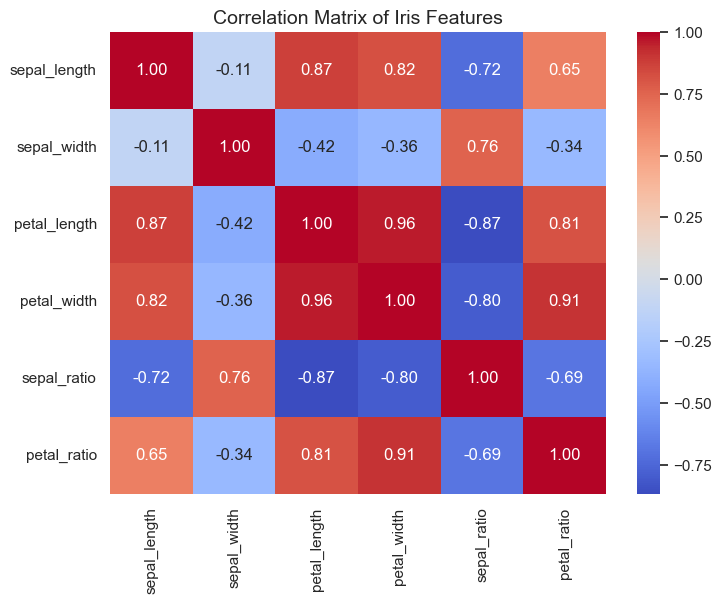

In [1123]:
# Correlation matrix for numerical features
corr_matrix = df.corr(numeric_only=True)

print("Correlation Matrix:\n")
print(corr_matrix)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Iris Features", fontsize=14)
plt.show()

## Conclusions
The correlation matrix for the Iris dataset confirms all previous analyses.  
The *Iris-setosa* class differs significantly from the others, correlations between its features are weaker and less consistent, reflecting its distinct physical characteristics.  
The **petal length** feature shows a strong correlation with several other variables, making it a good candidate for predicting the iris class.  
It can serve as a key variable when building classification models.

---

# SUMMARY AND FINAL CONCLUSIONS
## Assessment of Data Suitability for Classification Modeling:
The iris flower measurement data are of high quality — they contain no missing values and show clear feature distinctions between species.  
This makes them a solid foundation for building a classification model using classical statistical or machine learning methods.  
Preliminary analyses indicate the potential for achieving high classification accuracy, confirming the dataset’s usefulness as training material.
## Key Features Differentiating Iris Species:
The most distinctive features that effectively separate the species are:
- **Petal length**
- **Petal width**
These two features show the greatest inter-species variance and the lowest intra-species variance, making them excellent predictors for classification.
## Summary of Main Observations:
The analysis of the Iris dataset revealed clear differences between species in the dimensions of various flower parts, such as sepal and petal length and width.  
In particular, *Iris-virginica* exhibits significantly larger petal measurements compared to *Iris-setosa* and *Iris-versicolor*.  
Conversely, *Iris-setosa* is characterized by much smaller dimensions than the other two species.


In [1125]:
df.to_csv('25__homework__module_4_1.csv', index=False)